In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import argparse
import json
import tqdm
import io
import tarfile
import os
import math
import scipy
import itertools

import matplotlib.ticker as mtick
from itertools import chain
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev, median
from pathlib import Path

# serial #s uniquely identifying the chaip are located in the top left corner of each tile, when looking at it with 
# the power and data connectors at the top
tile_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                 '4k00952', '4k03591', '4k03936', '4k00607', \
                 '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']

# if certain channels are known to be problematic, and you don't want them skewing test distributions,
# specify them here.
omitted_channels = [56,57]
#omitted_channels = []

# only 6 tiles had successful linearity tests. Their average results will be used for the other tiles
tiles_tested_for_linearity = [17,18,20,21,22,24]

# establish filename that holds the results dictionary
temp = 'cold'
first_tile = 1
last_tile = 24
chip_version  = "v3a"
date = "2026-06-29_08:29"
results_filename = f'/data/v3/10x16/results_{chip_version}_tiles_{first_tile}-{last_tile}_{temp}_created_{date}.hdf5'

# initialize
verbose = True

In [2]:
# import the dictionary which logs test results by channel for all v3a tests
def import_results_dictionary():

    global results, tile_result_keys, results_filename

    # serial #s uniquely identifying the chip located in the top left corner of each tile, when looking at it with 
    # the power and data connectors at the top. The following key is needed when storing results in the dictionary
    tile_result_keys = ['', '4k04582', '4k04905', '4k03080', '4k04087', '4k04249', '4k00104', '4k01300', '4K04411', '4K01733', '4K00770', \
                     '4k00952', '4k03591', '4k03936', '4k00607', \
                     '4k01892', '4k02056', '4k02219', '4k02371', '4k00450', '4k04834', '4k00101', '4K00277', '4K03329', '4K03496']

    results = {}
    
    with h5py.File(results_filename, "r") as f:
        results = {}
        for key, item in f.items():
            data = item[()]
            results[key] = data    

    print(f'\nResults dictionary read from file {results_filename}\n')
          
    return


In [3]:
def store_results():

    global results, results_filename
    
    with h5py.File(results_filename, 'w') as f:
        
        for key, chan_list in results.items():
            f.create_dataset(key, data=np.array(chan_list))
    
        f.close()  

    print(f"\nResults corrected for hot channels in {results_filename}")  
    

In [4]:
def fix_hot_channels(results):

    global results_filename
    
    results["hot_channel"] =[[[1E8 for chan in range(64)] for chip in range(171)] for tile in range(25)]     

    # load hot channels. Most tests were run with these channels disabled
    tiles = [ 1, 1, 1,  1,   3,  4, 9, 9, 9, 9,10,10, 10,10,16, 17,21,23]
    chips = [20,32,110,110,101,156,20,60,60,60,50,50,103,50,60,160,21,86]
    chans = [ 4,26, 21, 22, 59, 63, 3, 5, 7,10,58,59, 60,37,26, 25,47,54]

    n = 0
    
    for i in range(18):
        results['hot_channel'][tiles[i]][chips[i]][chans[i]] = 1
        n +=1

    return    

In [5]:
'''

    Two sets of failures are logged. Specification Failures are more strict. They indicate if the
    channel/chip meets v3a specification criteria. Disable Failures indicate the problem is bad enough that the
    channel/chip should be disabled.

'''

def count_failures(results):

    global omitted_channels, tile_result_keys, tiles_tested_for_linearity, failures, spec_requirement, dis_requirement, metric_keys

    if len(omitted_channels) > 0:
        print(f"Channels {omitted_channels} were omitted from this analysis")
    
    # initialize
    n_misnumbered = 0
    spec_req, dis_req, spec_requirement, dis_requirement = {}, {}, {}, {}
                 
    # These metrics will be used to grade performance. Their order here will determine the order of cumulative measurements.
    metric_keys = ['hydra_failure', 'hot_channel', 'invalid_parity','misnumbered_chip', 'inl', 'inl_std', \
                   'dnl','pedestal_stdev','pedestal_kurtosis','leakage_scaling', 'missing_syncs', 'pedestal_mean',  \
                   'gain','pedestal_skew', 'leakage_hot', 'missing_words' ]

    failures = { metric: {'stand_alone_spec': 0, 'stand_alone_outlier': 0, 'cumulative_spec' : 0, 'cumulative_outlier' : 0}  for metric in metric_keys }

    spec_req['hydra_failure']  = []
    spec_req['hot_channel']     = []   
    spec_req['invalid_parity'] = [.5]
    spec_req['misnumbered_chip'] = []
    spec_req['inl']              = [-1]
    spec_req['inl_std']          = [1]
    spec_req['dnl']              = [1]
    spec_req['pedestal_stdev']   = [1]
    spec_req['pedestal_kurtosis'] = [2]
    spec_req['missing_syncs']     = [-1, .8]
    spec_req['gain']              = [3.7, 4.4]
    spec_req['pedestal_skew']     = [2]
    spec_req['leakage_noisy']     = [3]
    spec_req['leakage_scaling']   = [1]
    spec_req['pedestal_mean']     = [16, 46]
    spec_req['leakage_hot']       = [100]
    spec_req['missing_words']     = [100]
    
    spec_requirement['hydra_failure']     = "Failed hydra configure"
    spec_requirement['hot_channel']       = "Hot Channels"
    spec_requirement['pedestal_mean']     = "Central Mean Pedestal +/- 15 ke"
    spec_requirement['pedestal_stdev']    = "Pedestal Stdev > 1ke" 
    spec_requirement['pedestal_skew']     = "abs(Pedestal Skew) > 2"       
    spec_requirement['pedestal_kurtosis'] = "Pedestal Kurtosis > 2" 
    spec_requirement['invalid_parity']    = "Chips passing > 50% invalid pkts"
    spec_requirement['misnumbered_chip']  = "Flipped Chip ID Bit" 
    spec_requirement['leakage_hot']       = "Mean(Leakage) - Mean(Pedestal) > 100"
    spec_requirement['leakage_scaling']   = "Leakage Scaling > 1"
    spec_requirement['leakage_noisy']     = "Leakage Noisy > 3"    
    spec_requirement['missing_syncs']     = "Missing > 80% Syncs"
    spec_requirement['gain']              = "3.7 < Gain < 4.4 (3SD)"
    spec_requirement['missing_words']     = "Empty Word Bins > 100"
    spec_requirement['dnl']               = "DNL > 1"
    spec_requirement['inl']               = "INL < -1"
    spec_requirement['inl_std']           = "Stdev(INL-Fit Line) > 1"         

    dis_req['hydra_failure']     = []
    dis_req['hot_channel']       = []   
    dis_req['invalid_parity']    = [.5]
    dis_req['misnumbered_chip']  = []
    dis_req['missing_syncs']     = [-1,.8]
    dis_req['leakage_hot']       = [100]
    dis_req['missing_words']     = [100]
    dis_req['inl']               = [-10]
    dis_req['inl_std']           = [2]
    dis_req['dnl']               = [10]
    dis_req['pedestal_stdev']    = [1.2]
    dis_req['pedestal_kurtosis'] = [3]
    dis_req['gain']              = [3,5]
    dis_req['pedestal_skew']     = [2]
    dis_req['leakage_scaling']   = [1]
    dis_req['leakage_noisy']     = [3]    
    dis_req['pedestal_mean']     = [16, 46]
    
    dis_requirement['missing_syncs']     = "Missing > 80% Syncs" 
    dis_requirement['missing_words']     = "Empty Word Bins > 100"
    dis_requirement['hydra_failure']     = "Failed hydra configure"
    dis_requirement['invalid_parity']    = "Invalid Pkts > 50%"
    dis_requirement['leakage_hot']       = "Leakage Hot Channels"
    dis_requirement['hot_channel']       = "Hot Channels"
    dis_requirement['misnumbered_chip']  = "Misnumbered Chip" 
    dis_requirement['dnl']               = "DNL > 10"
    dis_requirement['inl']               = "INL < -10"    
    dis_requirement['inl_std']           = "Stdev(INL-Fit Line) > 2"    
    dis_requirement['pedestal_mean']     = "Central Ped Mean +/- 15ke-"
    dis_requirement['pedestal_stdev']    = "Pedestal Stdev > 1.2ke"       
    dis_requirement['pedestal_kurtosis'] = "Pedestal Kurtosis > 3" 
    dis_requirement['pedestal_skew']     = "abs(Pedestal Skew) > 3"  
    dis_requirement['gain']              = "3 < Gain > 5" 
    dis_requirement['leakage_scaling']   = "Leakage Scaling > 1"
    dis_requirement['leakage_noisy']     = "Leakage Noisy > 3" 
    
    # this subset of metrics will have their distributions graphed
    graph_metric_keys = ['pedestal_mean', 'pedestal_stdev', 'pedestal_skew', 'pedestal_kurtosis', \
               'leakage_mean', 'missing_syncs', 'gain', 'missing_words', 'dnl', 'inl', 'inl_std']
    
    # two different sets of failure thresholds are logged. Specification Failures are more strict. They indicate if the
    # channel/chip meets v3a specification criteria. Disable Failures indicate the problem is bad enough that the
    # channel/chip should be disabled.
    spec_failure    = {metric: [[[1E8 for chan in range(64)] for chip in range(171)] for tile in range(25)] for metric in metric_keys}
    disable_failure = {metric: [[[1E8 for chan in range(64)] for chip in range(171)] for tile in range(25)] for metric in metric_keys}    
    
    # create lists of each metric for graphing
    for tile in range(1,25):

        # most tests were not run for tile 4k00952 because it continually failed to hydra configure
        if tile == 11:
            continue
            
        # misnumbered chips are measured at the tile level because by its nature we don't know the
        # location of the origination chip. The numbered of channels from a misnumbered chip is stored
        # in channel 0 or chip 11 from each tile
        if results['misnumbered_chip'][tile][11][0] != 1E8:
                    
            misnumbered = results['misnumbered_chip'][tile][11][0]

            spec_failure['misnumbered_chip'][tile][11][0] = misnumbered
            disable_failure['misnumbered_chip'][tile][11][0] = misnumbered
            n_misnumbered += misnumbered
        
        for chip in range(11,171):

            for chan in range(64):
                
                # some channels are initalized to be omitted because of issues like proximity to analogue monitor pin
                if chan in omitted_channels:
                    continue

                # results are initialized to 1E8 to distinguish between channels with a metric value of 0 and channel's
                # which, for whatever reason, did not record a value

                '''
                pedestal metrics

                '''
                
                if results['pedestal_mean'][tile][chip][chan] != 1E8:

                    pedestal_mean = results['pedestal_mean'][tile][chip][chan]
                    
                    if pedestal_mean < spec_req['pedestal_mean'][0] or pedestal_mean > spec_req['pedestal_mean'][1]:
                        spec_failure['pedestal_mean'][tile][chip][chan] = 1
                    else:
                        spec_failure['pedestal_mean'][tile][chip][chan] = 0


                    if pedestal_mean < dis_req['pedestal_mean'][0] or pedestal_mean > dis_req['pedestal_mean'][1]:
                        disable_failure['pedestal_mean'][tile][chip][chan] = 1
                    else:
                        disable_failure['pedestal_mean'][tile][chip][chan] = 0

                
                if results['pedestal_stdev'][tile][chip][chan] != 1E8:
                    
                    pedestal_stdev = results['pedestal_stdev'][tile][chip][chan]
                    
                    if pedestal_stdev > spec_req['pedestal_stdev'][0]:
                        spec_failure['pedestal_stdev'][tile][chip][chan] = 1
                    else:
                        spec_failure['pedestal_stdev'][tile][chip][chan] = 0                        
                    
                    if pedestal_stdev > dis_req['pedestal_stdev'][0]:
                        disable_failure['pedestal_stdev'][tile][chip][chan] = 1  
                    else:
                        disable_failure['pedestal_stdev'][tile][chip][chan] = 0 
                
                if results['pedestal_skew'][tile][chip][chan] != 1E8:
                    
                    pedestal_skew = abs(results['pedestal_skew'][tile][chip][chan])
                    
                    if pedestal_skew > spec_req['pedestal_skew'][0]:
                        spec_failure['pedestal_skew'][tile][chip][chan] = 1
                    else:
                        spec_failure['pedestal_skew'][tile][chip][chan] = 0 
                    
                    if pedestal_skew > dis_req['pedestal_skew'][0]:
                        disable_failure['pedestal_skew'][tile][chip][chan] = 1
                    else:
                        disable_failure['pedestal_skew'][tile][chip][chan] = 0 
                        
                if results['pedestal_kurtosis'][tile][chip][chan] != 1E8:
                    
                    pedestal_kurt = results['pedestal_kurtosis'][tile][chip][chan]
                    
                    if pedestal_kurt > spec_req['pedestal_kurtosis'][0]:
                        spec_failure['pedestal_kurtosis'][tile][chip][chan] = 1
                    else:
                        spec_failure['pedestal_kurtosis'][tile][chip][chan] = 0
                    
                    if pedestal_kurt > dis_req['pedestal_kurtosis'][0]:
                        disable_failure['pedestal_kurtosis'][tile][chip][chan] = 1
                    else:
                        disable_failure['pedestal_kurtosis'][tile][chip][chan] = 0
 
                '''
                linearity metrics

                '''
                
                if results['dnl'][tile][chip][chan] != 1E8:

                    if results['dnl'][tile][chip][chan] > spec_req['dnl'][0]:
                        spec_failure['dnl'][tile][chip][chan] = 1
                    else:
                        spec_failure['dnl'][tile][chip][chan] = 0
                        
                    if results['dnl'][tile][chip][chan] > dis_req['dnl'][0]:
                        disable_failure['dnl'][tile][chip][chan] = 1 
                    else:
                        disable_failure['dnl'][tile][chip][chan] = 0 

                if results['inl'][tile][chip][chan] != 1E8:

                    if results['inl'][tile][chip][chan] < spec_req['inl'][0]:
                        spec_failure['inl'][tile][chip][chan] = 1
                    else:
                        spec_failure['inl'][tile][chip][chan] = 0
                        
                    if results['inl'][tile][chip][chan] < dis_req['inl'][0]:
                        disable_failure['inl'][tile][chip][chan] = 1 
                    else:
                        disable_failure['inl'][tile][chip][chan] = 0                 

                if results['inl_std'][tile][chip][chan] != 1E8:

                    if results['inl_std'][tile][chip][chan] > spec_req['inl_std'][0]:
                        spec_failure['inl_std'][tile][chip][chan] = 1
                    else:
                        spec_failure['inl_std'][tile][chip][chan] = 0
                        
                    if results['inl_std'][tile][chip][chan] > dis_req['inl_std'][0]:
                        disable_failure['inl_std'][tile][chip][chan] = 1 
                    else:
                        disable_failure['inl_std'][tile][chip][chan] = 0

                '''
                leakage metrics

                '''
                
                if results['leakage_scaling'][tile][chip][chan] != 1E8:
                                
                    l_mean  = results['leakage_mean'][tile][chip][chan]
                    l_stdev = results['leakage_stdev'][tile][chip][chan]
                    l_scale = results['leakage_scaling'][tile][chip][chan]
                    p_stdev = results['pedestal_stdev'][tile][chip][chan]
                    
                    # identify channels that only become noisy in leakage tests and scale with trigger cycles                 
                    if l_scale > spec_req['leakage_scaling'][0] and l_stdev > spec_req['leakage_noisy'][0] and p_stdev < spec_req['pedestal_stdev'][0]:
                    #if l_scale > 1 and l_stdev > 3 and p_stdev < 1:
                        spec_failure['leakage_scaling'][tile][chip][chan] = 1
                    else:
                        spec_failure['leakage_scaling'][tile][chip][chan] = 0   
                    
                    # identify leakage hot channels (high mean and low stdev)
                    if l_mean > spec_req['leakage_hot'][0] and l_stdev < spec_req['leakage_noisy'][0]:
                        spec_failure['leakage_hot'][tile][chip][chan] = 1
                        disable_failure['leakage_hot'][tile][chip][chan] = 1 
                    else:
                        spec_failure['leakage_hot'][tile][chip][chan] = 0
                        disable_failure['leakage_hot'][tile][chip][chan] = 0                               

                    if l_scale > dis_req['leakage_scaling'][0] and l_stdev > dis_req['leakage_noisy'][0] and p_stdev < spec_req['pedestal_stdev'][0]:
                        disable_failure['leakage_scaling'][tile][chip][chan] = 1
                    else:
                        disable_failure['leakage_scaling'][tile][chip][chan] = 0 
                        
                '''
                Other metrics

                '''
              
                if results['hot_channel'][tile][chip][chan] == 1:
                                
                    spec_failure['hot_channel'][tile][chip][chan] = 1
                    disable_failure['hot_channel'][tile][chip][chan] = 1

                if results['hydra_failure'][tile][chip][chan] == 1:
                                
                    spec_failure['hydra_failure'][tile][chip][chan] = 1
                    disable_failure['hydra_failure'][tile][chip][chan] = 1      

                if results['missing_syncs'][tile][chip][chan] != 1E8:
                                
                    if results['missing_syncs'][tile][chip][chan] > spec_req['missing_syncs'][1] or results['missing_syncs'][tile][chip][chan] < spec_req['missing_syncs'][0]:
                        spec_failure['missing_syncs'][tile][chip][chan] = 1
                        disable_failure['missing_syncs'][tile][chip][chan] = 1
                    else:
                        spec_failure['missing_syncs'][tile][chip][chan] = 0
                        disable_failure['missing_syncs'][tile][chip][chan] = 0                        

                if results['gain'][tile][chip][chan] != 1E8:

                    gain = results['gain'][tile][chip][chan]
                    
                    if gain < spec_req['gain'][0] or gain > spec_req['gain'][1]:
                        spec_failure['gain'][tile][chip][chan] = 1
                    else:
                        spec_failure['gain'][tile][chip][chan] = 0                        

                    if gain < dis_req['gain'][0] or gain > dis_req['gain'][1]:
                        disable_failure['gain'][tile][chip][chan] = 1
                    else:
                        disable_failure['gain'][tile][chip][chan] = 0   
                
                if results['missing_words'][tile][chip][chan] != 1E8:

                    n_missing = results['missing_words'][tile][chip][chan]

                    if n_missing < spec_req['missing_words'][0]:                        
                        spec_failure['missing_words'][tile][chip][chan] = 0
                        disable_failure['missing_words'][tile][chip][chan] = 0
                    else:
                        spec_failure['missing_words'][tile][chip][chan] = 1                        
                        disable_failure['missing_words'][tile][chip][chan] = 1                        
                
                if results['invalid_parity'][tile][chip][chan] != 1E8:
                                
                    if results['invalid_parity'][tile][chip][chan] >= spec_req['invalid_parity'][0]:
                        spec_failure['invalid_parity'][tile][chip][chan] = 1                      
                    
                    if results['invalid_parity'][tile][chip][chan] >= dis_req['invalid_parity'][0]:
                        disable_failure['invalid_parity'][tile][chip][chan] = 1

    
    '''
    Tally Specification Failures by metric
    
    '''
    
    print(f"\nSpecification Failure Counts:")

    n_keys = len(metric_keys)    
    n_failures, n_chans, percents, lists, means = {}, {}, {}, {}, {}
    failure_list, requirement_list, stand_alone_list = [], [], []
    
    for i in range(n_keys):

        metric = metric_keys[i]
        
        n_failures[metric] = sum(1 for tile in spec_failure[metric] for chip in tile for chan in chip if chan == 1)
        n_chans[metric] = sum(1 for tile in spec_failure[metric] for chip in tile for chan in chip if chan == 1 or chan == 0)

    for i in range(n_keys):

        metric = metric_keys[i]        
        
        # the failure and n_chan counts above have to be adapted for certain metrics
        # all channels were tested for hot channels and hydra failures
        if metric == 'hydra_failure' or metric == 'hot_channel':
            n_chans[metric] = 23 * 160 * 64
        
        # invalid parity was detected from pedestal tests  
        elif metric == "invalid_parity":
            n_chans[metric] = n_chans['pedestal_mean']
        
        # misnumbered chips were all assigned to channel 0 of chip 11. They are tallied specially above
        elif metric == "misnumbered_chip":
            n_chans[metric] = n_chans['pedestal_mean']
            n_failures[metric] = int(n_misnumbered)

        elif metric == "missing_syncs":
            n_chans[metric] = n_chans['pedestal_mean'] 
            
        # only a subset of tiles were successfully tested for linearity
        elif metric in ["inl", "dnl", "inl_std"]: 
            avg_linearity = n_failures[metric] / len(tiles_tested_for_linearity) 
            avg_n_tested =  n_chans[metric] / len(tiles_tested_for_linearity)
            n_failures[metric] = int( avg_linearity * 23 )            
            n_chans[metric]    = int( avg_n_tested  * 23 ) 

        if n_chans[metric] > 0:
            percents[metric] = 100 * n_failures[metric] / n_chans[metric]
            print(f"\t{int(n_failures[metric])} channels ({percents[metric]:.4f}%)\t {spec_requirement[metric]}")
        
        else:
            print(f"\t{int(n_failures[metric]):} channels\t {spec_requirement[metric]}")

        # make lists of certain results for graphing
        if metric in graph_metric_keys or metric in ['leakage_hot', 'leakage_noisy']:

            # leakage metrics are labeled differently between the results dictionary and the failure dictionary  
            if metric == 'leakage_hot':
                lmetric = 'leakage_mean'
            else:
                lmetric = metric
            
            lists[lmetric] = []
            
            for tile in range(25):
                for chip in range(11,171):
                    for chan in range(64):
                        if results[lmetric][tile][chip][chan] != 1E8:
                            lists[lmetric].append(results[lmetric][tile][chip][chan])
        
        # make a list of the # of failures per metric
        failure_list.append(percents[metric])
        requirement_list.append(spec_requirement[metric])         
        stand_alone_list.append(n_failures[metric])

        failures[metric]['stand_alone_spec'] = n_failures[metric]
    
    n_omitted = 23*160*len(omitted_channels)
    percent_omitted = 100 * n_omitted / (23*160*64)        
    print(f"\t{n_omitted:.0f} Channels ({percent_omitted:.1f}%)\t Near analogue monitor pin\n\n")

    ''' crudely distinguish purely noisy channels from jumpy channels '''

    n_noisy, n_jumpy_high_std, n_jumpy_low_std = 0, 0, 0 
    
    for i in range(len(lists['pedestal_stdev'])):
        if lists['pedestal_stdev'][i] > spec_req['pedestal_stdev'][0]:
            if lists['pedestal_kurtosis'][i] < spec_req['pedestal_kurtosis'][0]:
                n_noisy +=1
            else:
                n_jumpy_high_std +=1
        else:
            if lists['pedestal_kurtosis'][i] > spec_req['pedestal_kurtosis'][0]:
                n_jumpy_low_std +=1

    percent_noisy = 100 * n_noisy / (23*160*64) 
    percent_jumpy_low  = 100 * n_jumpy_low_std  / (23*160*64)    
    percent_jumpy_high = 100 * n_jumpy_high_std / (23*160*64)  

    print(f"\nCrude estamation of jumpy versus noisy channels:")    
    print(f"\tNoisy channels wo jumps  = {n_noisy} or {percent_noisy:.1f}%")
    print(f"\tJumpy channels, high std = {n_jumpy_high_std} or {percent_jumpy_high:.1f}%")    
    print(f"\tJumpy channels,  low std = {n_jumpy_low_std} or {percent_jumpy_low:.5f}%")    

    ''' find leakage noisy that weren't pedestal noisy '''

    n_noisy_both, n_noisy_leakage = 0, 0 
    
    for tile in range(25):
        for chip in range(11,171):
            for chan in range(64):
                if results["leakage_stdev"][tile][chip][chan] != 1E8 and results["pedestal_stdev"][tile][chip][chan] != 1E8:
                    if results['leakage_stdev'][tile][chip][chan] > spec_req['leakage_noisy'][0]:
                        if results['pedestal_stdev'][tile][chip][chan] > spec_req['pedestal_stdev'][0]:
                            n_noisy_both +=1
                        else:
                            n_noisy_leakage +=1

    percent_both = 100 * n_noisy_both / (23*160*64) 
    percent_leak  = 100 * n_noisy_leakage  / (23*160*64)    

    print(f"\nNoisy leakage channels:")    
    print(f"\tNoisy in Pedestal and Leakage tests  = {n_noisy_both} or {percent_both:.1f}%")
    print(f"\tOnly noisy in Leakage test = {n_noisy_leakage} or {percent_leak:.1f}%")    
    
    ''' graph failure rates per metric'''

    # sort failure rates by value in descending order
    indices = np.argsort(failure_list)[::-1]
    sorted_reqs  = [requirement_list[i] for i in indices]
    sorted_fails = [failure_list[i] for i in indices]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(sorted_reqs, sorted_fails, color="skyblue")
    ax.bar_label(bars, padding=3, fmt='%.1f')
    ax.set_title("Stand Alone Specification Failure Percentages\n23 v3a tiles tested cold Spring 2026")
    ax.text(6, 12, "5% CRO-019", color = 'r')
    ax.axvline(x = 5, color='r', linestyle='--')
    ax.set_xscale('log')
    ax.set_xlim(0,200)
    ax.set_xlabel("Failure Rate (%)")
    plt.tight_layout()
    plt.show()

    ''' Graph distributions for select metrics '''

    graph_metric_distributions(lists, percents, spec_requirement, dis_requirement, graph_metric_keys, spec_req, dis_req)
    
    ''' Graph Correlations '''
    
    # graph correlations between various metrics
    metric_1 = ['pedestal_stdev'    , 'leakage_stdev' ,     'pedestal_skew',     'dnl', 'gain']
    metric_2 = ['pedestal_kurtosis' , 'pedestal_stdev', 'pedestal_kurtosis', 'inl_std', 'inl_std']
    req_1    = [ 1.2,  3,  2,  1,   5]
    req_2    = [   2,1.2,  2,  1,   1]
    minx     = [   0,  0, -7,  0, 2.5] 
    maxx     = [   7, 14,  7,  8,   5]
    miny     = [  -4,  0, -4, -1,  -1]
    maxy     = [  40,  7, 40,  7,  20]

    for m in range(len(metric_1)):
        graph_stand_alone_correlations(results[metric_1[m]], results[metric_2[m]], metric_1[m], metric_2[m], req_1[m], req_2[m], minx[m], maxx[m], miny[m], maxy[m])

    ''' Compare stand alone versus Cumulative failures for Specification Criteria '''
    
    cumulative_failures(results, stand_alone_list, metric_keys, spec_requirement, spec_req, True)
    
    '''
    Tally alternative criteria failures and percentages on a stand alone basis
    
    '''
    
    print(f"\nAlternative Criteria Failure Counts:")

    n_keys = len(metric_keys)  
    n_failures, percents = {}, {}
    failure_list, requirement_list, stand_alone_list = [], [], []
    
    for i in range(n_keys ):

        metric = metric_keys[i]        
        n_failures[metric] = sum(1 for tile in disable_failure[metric] for chip in tile for chan in chip if chan == 1)

        if metric == "misnumbered_chip":
            n_failures[metric] = int(n_misnumbered)
        elif metric in ["inl", "dnl", "inl_std"]:     # only a subset of tiles were tested for linearity
            n_failures[metric] = int( n_failures[metric] * 23 / len(tiles_tested_for_linearity) )

        # print the results
        if n_chans[metric] > 0:
            percents[metric] = 100 * n_failures[metric] / n_chans[metric]
            print(f"\t{int(n_failures[metric])} channels ({percents[metric]:.4f}%)\t {dis_requirement[metric]}")
        else:
            print(f"\t{int(n_failures[metric])} channels\t {dis_requirement[metric]}")

        failure_list.append(percents[metric])      
        requirement_list.append(dis_requirement[metric]) 
        stand_alone_list.append(n_failures[metric])

        failures[metric]['stand_alone_outlier'] = n_failures[metric]

    # if during initialization the user chose to omit certain channels, they are tallied here
    n_omitted = 23*160*len(omitted_channels)
    percent_omitted = 100 * n_omitted / (23*160*64)        
    print(f"\t{n_omitted:.0f} Channels ({percent_omitted:.1f}%)\t Near analogue monitor pin\n\n")

    ''' sort and graph stand alone alternative criteria failure rates '''

    # sort disable failure rates by value in descending order
    indices = np.argsort(failure_list)[::-1]
    sorted_reqs  = [requirement_list[i] for i in indices]
    sorted_fails = [failure_list[i] for i in indices]

    y = range(len(sorted_fails))
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(sorted_reqs, sorted_fails, color="skyblue")
    ax.bar_label(bars, padding=3, fmt='%.1f')   
    #ax.set_yticks(y) 
    #ax.set_yticklabels(sorted_reqs)  
    ax.axvline(x = 5, color='r', linestyle='--')
    ax.set_title("Stand Alone Alternative Failure Percentages\n 23 v3a tiles tested cold Spring 2026")
    ax.set_xscale('log')
    ax.set_xlim(0,200)
    ax.set_xlabel("Failure Percentage (%)")
    ax.text(6, 12, "5% CRO-019", color = 'r')
    
    plt.tight_layout()
    plt.show()

    ''' Compare the stand alone vs cumulative alternative failure counts '''
       
    cumulative_failures(results, stand_alone_list, metric_keys, dis_requirement, dis_req, False)
    
    return
    

In [6]:
def graph_stand_alone_correlations(list1, list2, label_x, label_y, vline, hline, minx, maxx, miny,maxy):

    list_x, list_y = [],[]
    
    for tile in range(25):
        for chip in range(11,171):
            for chan in range(64):
                if list1[tile][chip][chan] != 1E8 and list2[tile][chip][chan] != 1E8:
                    list_x.append(list1[tile][chip][chan])
                    list_y.append(list2[tile][chip][chan])

                
    graph_title1 = f"{label_x} VS {label_y}\ncold test of 23 v3a tiles"
    graph_title2 = f"Zoom into {label_x} VS {label_y}\ncold test of 23 v3a tiles"            

    fig, ax = plt.subplots(1,2, figsize=(10,3))
    
    ax[0].scatter(list_x, list_y, alpha = 0.04)
    ax[0].set_title(graph_title1)
    ax[0].set_xlabel(label_x)    
    ax[0].set_ylabel(label_y) 
    ax[0].axvline(x = vline, color='r', linestyle='--') 
    ax[0].axhline(y = hline, color='r', linestyle='--')     

    ax[1].scatter(list_x, list_y, alpha = 0.04)
    ax[1].set_title(graph_title2)
    ax[1].set_xlim(minx, maxx)
    ax[1].set_ylim(miny, maxy)    
    ax[1].set_xlabel(label_x)    
    ax[1].set_ylabel(label_y) 
    ax[1].axvline(x = vline, color='r', linestyle='--') 
    ax[1].axhline(y = hline, color='r', linestyle='--')     

    
    plt.show
    
    return

In [7]:
'''
 
Totals the number of channels that fail without double counting the ones that have already failed a previous 
failure mode (as they are listed in this function). 

'''

def cumulative_failures(results, stand_alone_list, metric_keys, cumulative_requirement, reqs, specification):

    global omitted_channels, tile_result_keys, tiles_tested_for_linearity, failures

    # initialize
    n_misnumbered = 0      
    
    # for alternative criteria INL and DNL will be ignored
    alternative_ignore = ['inl', 'dnl']
    
    # Cumulative failures indicate a channel failed the criteria, but passed all previous criteria (as ordered in this function)
    cumulative_failure = {metric: [[[1E8 for chan in range(64)] for chip in range(171)] for tile in range(25)] for metric in metric_keys}    
    
    # create lists of each metric for graphing. Each result is initialized to 1E8. Those channel results should be ignored. 
    for tile in range(1,25):

        # most tests were not run for tile 4k00952 because it continually failed to hydra configure
        if tile == 11:
            continue
    
        # the original location of misnumbered chips  is unknown so they were all assigned to chip 11 channel 0
        if results['misnumbered_chip'][tile][11][0] != 1E8:
                    
            misnumbered = results['misnumbered_chip'][tile][11][0]

            cumulative_failure['misnumbered_chip'][tile][11][0] = misnumbered
            n_misnumbered += misnumbered
        
        for chip in range(11,171):

            for chan in range(64):
                
                # some channels are initalized to be omitted because of issues like proximity to analogue monitor pin
                if chan in omitted_channels:
                    continue

                # if the chip failed to hydra configure it was disabled before running the tests
                if results['hydra_failure'][tile][chip][chan] == 1:
                    cumulative_failure['hydra_failure'][tile][chip][chan] = 1
                    continue

                # hot channels were (or should have been) disabled before running the tests
                if results['hot_channel'][tile][chip][chan] == 1:
                                
                    cumulative_failure['hot_channel'][tile][chip][chan] = 1
                    continue                

                # ignore results from chips that passed > 50% invalid packets
                if results['invalid_parity'][tile][chip][chan] != 1E8:
                                
                    if results['invalid_parity'][tile][chip][chan] >= reqs['invalid_parity'][0]:
                        cumulative_failure['invalid_parity'][tile][chip][chan] = 1 
                        continue 

                # only use INL and DNL criteria for Specification criteria. Ignore for Alternative Criteria
                if specification:
                    
                    if results['inl'][tile][chip][chan] != 1E8:
                        
                        if results['inl'][tile][chip][chan] < reqs['inl'][0]:
                            cumulative_failure['inl'][tile][chip][chan] = 1 
                            continue
                        else:
                            cumulative_failure['inl'][tile][chip][chan] = 0 

                    if results['dnl'][tile][chip][chan] != 1E8:
                            
                        if results['dnl'][tile][chip][chan] > reqs['dnl'][0]:
                            cumulative_failure['dnl'][tile][chip][chan] = 1 
                            continue
                        else:
                            cumulative_failure['dnl'][tile][chip][chan] = 0 
                
                # the rest of the metrics are roughly ordered with the most impactful first                
                if results['inl_std'][tile][chip][chan] != 1E8:
                        
                    if results['inl_std'][tile][chip][chan] > reqs['inl_std'][0]:
                        cumulative_failure['inl_std'][tile][chip][chan] = 1
                        continue
                    else:
                        cumulative_failure['inl_std'][tile][chip][chan] = 0         

                if results['pedestal_stdev'][tile][chip][chan] != 1E8:
                    
                    pedestal_stdev = results['pedestal_stdev'][tile][chip][chan]
                       
                    if pedestal_stdev > reqs['pedestal_stdev'][0]:
                        cumulative_failure['pedestal_stdev'][tile][chip][chan] = 1  
                        continue
                    else:
                        cumulative_failure['pedestal_stdev'][tile][chip][chan] = 0 
                                
                if results['pedestal_kurtosis'][tile][chip][chan] != 1E8:
                    
                    pedestal_kurt = results['pedestal_kurtosis'][tile][chip][chan]
                             
                    if pedestal_kurt > reqs['pedestal_kurtosis'][0]:
                        cumulative_failure['pedestal_kurtosis'][tile][chip][chan] = 1
                        continue
                    else:
                        cumulative_failure['pedestal_kurtosis'][tile][chip][chan] = 0                

                if results['missing_syncs'][tile][chip][chan] != 1E8:
                                
                    if results['missing_syncs'][tile][chip][chan] > reqs['missing_syncs'][1] or results['missing_syncs'][tile][chip][chan] < reqs['missing_syncs'][0]:
                        cumulative_failure['missing_syncs'][tile][chip][chan] = 1
                        continue
                    else:
                        cumulative_failure['missing_syncs'][tile][chip][chan] = 0     

                if results['leakage_scaling'][tile][chip][chan] != 1E8:
                                
                    l_mean  = results['leakage_mean'][tile][chip][chan]
                    l_stdev = results['leakage_stdev'][tile][chip][chan]                
                    l_scale = results['leakage_scaling'][tile][chip][chan]
                    p_stdev = results['pedestal_stdev'][tile][chip][chan]
                    
                    # identify channels that only become noisy in leakage tests and scale with trigger cycles                 
                    if l_scale > reqs['leakage_scaling'][0] and l_stdev > reqs['leakage_noisy'][0] and p_stdev < 1:
                        cumulative_failure['leakage_scaling'][tile][chip][chan] = 1
                        continue
                    else:
                        cumulative_failure['leakage_scaling'][tile][chip][chan] = 0 

                    # identify hot channels (high mean and low stdev)
                    if l_mean > reqs['leakage_hot'][0] and l_stdev < reqs['leakage_noisy'][0]:
                        cumulative_failure['leakage_hot'][tile][chip][chan] = 1 
                        continue
                    else:
                        cumulative_failure['leakage_hot'][tile][chip][chan] = 0  
                        
                if results['pedestal_mean'][tile][chip][chan] != 1E8:
                        
                    if results['pedestal_mean'][tile][chip][chan] > reqs['pedestal_mean'][1] \
                       or results['pedestal_mean'][tile][chip][chan] < reqs['pedestal_mean'][0]:
                        cumulative_failure['pedestal_mean'][tile][chip][chan] = 1 
                        continue
                    else:
                        cumulative_failure['pedestal_mean'][tile][chip][chan] = 0        
                   
                if results['gain'][tile][chip][chan] != 1E8:
                        
                    if results['gain'][tile][chip][chan] > reqs['gain'][1] or results['gain'][tile][chip][chan] < reqs['gain'][0]:
                        cumulative_failure['gain'][tile][chip][chan] = 1 
                        continue
                    else:
                        cumulative_failure['gain'][tile][chip][chan] = 0           
                        
                if results['pedestal_skew'][tile][chip][chan] != 1E8:
                        
                    if abs(results['pedestal_skew'][tile][chip][chan]) > reqs['pedestal_skew'][0]:
                        cumulative_failure['pedestal_skew'][tile][chip][chan] = 1 
                        continue
                    else:
                        cumulative_failure['pedestal_skew'][tile][chip][chan] = 0          
                        
                if results['pedestal_mean'][tile][chip][chan] != 1E8:
                        
                    if results['pedestal_mean'][tile][chip][chan] > reqs['pedestal_mean'][1] \
                       or results['pedestal_mean'][tile][chip][chan] < reqs['pedestal_mean'][0]:
                        cumulative_failure['pedestal_mean'][tile][chip][chan] = 1 
                        continue
                    else:
                        cumulative_failure['pedestal_mean'][tile][chip][chan] = 0        
    
    ''' Tally Cumulative Failures per metric    '''
    
    print(f"\nCumulative Failure Counts:")

    n_total_failures = 0
    
    n_keys = len(metric_keys)    
    n_failures, n_chans, percents, lists = {}, {}, {}, {}
    cumulative_failure_list, requirement_list, graph_stand_alone_list = [], [], []
    
    for i in range(n_keys):

        metric = metric_keys[i]
        
        n_failures[metric] = sum(1 for tile in cumulative_failure[metric] for chip in tile for chan in chip if chan == 1)
            
        # the count of channels from misnumbered chips are assigned to channels 0 of chip 11 on each 
        # tile because we don't know where they originated. They are tallied above
        if metric == "misnumbered_chip":
            n_failures[metric] = int(n_misnumbered)          
        
        # linearity metrics are normalized to recognize that only 6 out of 23 tiles were tested
        elif metric in ["inl", "dnl", "inl_std"]:     
            avg_linearity = int( n_failures[metric] / len(tiles_tested_for_linearity) )
            n_failures[metric] = avg_linearity * 23

        n_total_failures += n_failures[metric]
        
        if specification: 
            graph_stand_alone_list.append(stand_alone_list[i])
            cumulative_failure_list.append(n_failures[metric])
            requirement_list.append(cumulative_requirement[metric]) 
        
            print(f"\t{int(n_failures[metric])} channels\t {cumulative_requirement[metric]}")  

            failures[metric]['cumulative_spec'] = n_failures[metric]
        
        elif metric not in alternative_ignore: 
            graph_stand_alone_list.append(stand_alone_list[i])
            cumulative_failure_list.append(n_failures[metric])
            requirement_list.append(cumulative_requirement[metric]) 
        
            print(f"\t{int(n_failures[metric])} channels\t {cumulative_requirement[metric]}")              

            failures[metric]['cumulative_outlier'] = n_failures[metric]

    n_omitted = 23*160*len(omitted_channels)        
    print(f"\t{n_omitted:.0f} Channels\t Near analogue monitor pin\n\n")
    
    # print cumulative vs stand alone failure counts
    print(f"Stand Alone Failures\tCumulative Failures")
    for i in range(len(graph_stand_alone_list)):

        metric = metric_keys[i]       

        print(f"{graph_stand_alone_list[i]} \t{cumulative_failure_list[i]} \t {cumulative_requirement[metric]}")        
    
    ''' Graph Cumulative Failures VS Stand Alone Failures '''
    
    n_channels = 23 * 160 * 64
    
    percent_pre_omitted = 100 * n_total_failures / n_channels
    percent_omitted = 100 * n_omitted / n_channels  
        
    y = np.arange(len(cumulative_failure_list))
    width = 0.4

    fig, ax = plt.subplots(figsize=(8, 5))    

    if specification:
        
        graph_title = f"Specification Failures: Cumulative versus Stand Alone (Omitted Channels {omitted_channels})\
        \n{percent_pre_omitted:.0f}% of channels fail at least 1 specification requirement among 23 v3a tiles tested cold Spring 2026"   
        
        ax.axvline(x = n_channels * .05, color='r', linestyle='--')
        ax.text(n_channels * .055, 12, "5% CRO-019", color = 'r')
    
    else:
        
        graph_title = f"Alternative Criteria Failures: Cumulative versus Stand Alone (Omitted Channels {omitted_channels})\
        \n{percent_pre_omitted:.1f}% of channels fail at least 1 requirement among 23 v3a tiles tested cold Spring 2026"        
        ax.axvline(x = 5*2355, color='r', linestyle='--')
        ax.text((2500), 10, "5% CRO-019", color = 'r')
    
    ax.barh(y + width/2, graph_stand_alone_list, width, label='Stand Alone')
    ax.barh(y - width/2, cumulative_failure_list, width, label='Cumulative')
    ax.set_yticks(y) 
    ax.set_yticklabels(requirement_list)
    ax.set_xlabel(f"# Channels ({n_channels * .01:,.0f} channels = 1%)")
    ax.legend(loc='upper right')
    ax.set_title(graph_title)  
    ax.set_xscale("log")
    plt.show
    
    ''' Graph cumulative alternative criteria failures per Tile '''

    n_tiles = len(tile_result_keys)
    n_channels_per_tile = 160*64
    
    tile_grade = [0 for tile in range(n_tiles)]

    total_tile_failures = 0

    for tile in range(n_tiles):

        # most tests were not run for tile 4k00952 because it continually failed to hydra configure. It
        # will be handled separately. There is no tile 0
        if tile == 11 or tile == 0:
            continue
        
        for i in range(n_keys):
            
            metric = metric_keys[i] 
            
            # only 6 tiles were tested for linearity. Assign their average failure count to the rest
            if metric in ['inl','dnl','inl_std'] and tile not in tiles_tested_for_linearity:
                
                tile_grade[tile] += int(n_failures[metric] / 23)

            else:    
                for chip in range(11,171):
                    for chan in range(64):
                        if cumulative_failure[metric][tile][chip][chan] == 1:
                        
                            tile_grade[tile] += 1        

        total_tile_failures += tile_grade[tile]

    # sort cumulative failure rates by value in descending order
    indices = np.argsort(tile_grade)
    s_tile_grade  = [tile_grade[i] for i in indices]
    s_tile_result_keys = [tile_result_keys[i] for i in indices]

    # tile 4k00952 failed to hydra configure so it wasn't tested. It is given a grade of 1.2 * worst tile grade to ensure it is the highest
    t_index = s_tile_result_keys.index('4k00952')
    s_tile_grade[t_index] = 1.2 * max(s_tile_grade)
          
    percent_total = 100 * total_tile_failures / n_channels
    avg_tile_failures = int( total_tile_failures / 23 )
    avg_tile_percent = 100 * avg_tile_failures / (160 * 64)
          
    if not specification:
        graph_title = f"# Channels Failing Alternative Criteria per Tile (Omitted Channels {omitted_channels}) \n On average {avg_tile_failures:.0f} chanells ({avg_tile_percent:.0f}%) failed, 23 v3a tiles tested cold Spring 2026" 
     
        fig, ax = plt.subplots(figsize=(8, 5))    
        ax.barh(range(n_tiles), s_tile_grade)
        ax.barh(1, s_tile_grade[t_index], color = 'r')    
        ax.set_yticks(range(n_tiles))  
        ax.set_yticklabels(s_tile_result_keys)
        ax.axvline(x = avg_tile_failures, color='r', linestyle='--')
        ax.text(25 + avg_tile_failures, 6, f"{avg_tile_percent:.0f}%", color = 'r')    
        ax.set_xlabel(f"Tile Grades ({n_channels_per_tile * .01:,.0f} channels = 1%)")
        ax.set_title(graph_title)  
        plt.show
        
    return


In [8]:

def graph_metric_distributions(lists, percents, spec_requirement, dis_requirement, graph_metric_keys, spec_req, disable_req):  
    
    # graph distributions for a subset of metrics
    titles = ['Pedestal Mean', 'Pedestal Stdev', 'Pedestal Skew', 'Pedestal Kurtosis', \
               'Leakage Mean', 'Missing Syncs', 'Gain', 'Missing Words', 'DNL', 'INL', 'INL Stdev']

    xaxis = ['Pedestal Mean (ke-)', 'Pedestal Stdev (ke-)', 'Pedestal Skew', 'Pedestal Kurtosis', \
               'Leakage Mean (words)', 'Missing Syncs (%)', 'Gain', 'Missing Words', 'DNL', 'INL', 'INL Stdev']

    #zoom_range = {'missing_syncs': [-.1,1.1], 'gain': [2,6], 'missing_words': [2,25]}
    zoom_range = {'gain': [2,6], 'missing_words': [2,25]}    
    
    for i in range(len(graph_metric_keys)):

        metric = graph_metric_keys[i]
        
        # the metrics not identified in zoom_range will  only be graphed once
        if metric not in zoom_range:
        
            fig, ax = plt.subplots(figsize=(6, 3))
            
            if metric == 'leakage_stdev':
                graph_title = f"{titles[i]} by Channel\n {percents['leakage_noisy']:.1f}% failed {spec_requirement['leakage_noisy']} \ncold test of 23 v3a tiles"
                for j in range(len(   spec_req['leakage_noisy'])):    
                    ax.axvline(x = spec_req['leakage_noisy'][j],    color='r', linestyle='--')
                for j in range(len(disable_req['leakage_noisy'])):
                    ax.axvline(x = disable_req['leakage_noisy'][j], color='r', linestyle='-') 
            
            elif metric == 'leakage_mean':
                graph_title = f"{titles[i]} by Channel\n {percents['leakage_hot']:.1f}% failed {spec_requirement['leakage_hot']} \ncold test of 23 v3a tiles"
                for j in range(len(   spec_req['leakage_hot'])):    
                    ax.axvline(x = spec_req['leakage_hot'][j],    color='r', linestyle='--')
                for j in range(len(disable_req['leakage_hot'])):
                    ax.axvline(x = disable_req['leakage_hot'][j], color='r', linestyle='-') 
            
            else:         
                graph_title = f"{titles[i]} by Channel\n {percents[metric]:.1f}% failed {spec_requirement[metric]} \ncold test of 23 v3a tiles"
                for j in range(len(   spec_req[metric])):                
                    ax.axvline(x = spec_req[metric][j],    color='r', linestyle='--')
                for j in range(len(disable_req[metric])):
                    ax.axvline(x = disable_req[metric][j], color='r', linestyle='-') 
        
            if metric == 'inl':            
                metric_bins = max( 100, int(abs(min(lists[metric]))) )
            elif metric == 'missing_syncs':
                ax.set_xlim(-0.1, 1.1)
                metric_bins = 100
            elif metric == 'pedestal_mean':
                lists[metric] = [x for x in lists[metric] if x < 100]
                metric_bins = 100
            else:
                 metric_bins = max( 100, int(max(lists[metric])) )
            
            ax.set_title(graph_title)
            ax.hist( lists[metric], bins = metric_bins )
            ax.set_xlabel(xaxis[i])    
            ax.set_yscale('log')           
            ax.set_ylabel(f'Channel Count')            
            
            plt.show
    
            if metric == 'pedestal_stdev':
                nelectrons = [1, 1.2, 1.4, 1.6, 1.8, 2]
                high_std = []

                for n in nelectrons:
                    count = [x for x in lists[metric] if x > n] 
                    percent_high = 100 * len(count) / len(lists[metric])
                    high_std.append(percent_high)
                    print(f"\t{percent_high:.1f}% of channels had stdev > {n*1000:.0f} electrons")      
                    
                fig, ax = plt.subplots(figsize=(6,3))
                ax.set_title(f'Percent of Channels Failing a Variable Stdev Requirement\n{temp} test of 23 v3a Tiles')
                ax.scatter(nelectrons, high_std) 
                ax.set_xlabel('Noise Requirement (ke-)') 
                ax.set_ylabel('% of Channels that Fail')
                #plt.grid(axis='y', linestyle='--', linewidth=0.7, color='gray', alpha=0.7)
                ax.set_xlim(0.9, 2.2)
                for n in range(len(nelectrons)):
                    value = f"{high_std[n]:.1f}%"
                    plt.text(nelectrons[n] + .04, high_std[n]-0.25, value, color = 'r')
                
                plt.show
        
        # the metrics identified in zoom_range will be graphed with their full range and a range that zooms into the main distribution
        else:

            fig, ax = plt.subplots(1,2, figsize=(10, 4))
                   
            graph_title = f"{titles[i]} by Channel\n {percents[metric]:.1f}% failed {spec_requirement[metric]} cold test of 23 v3a tiles"

            if metric == "gain":
                metric_bins = 1000
            elif metric == "missing_words":
                print(f"\nMaximum missing words = {max(lists[metric])}")
                metric_bins = 400
            
            ax[0].set_xlabel(xaxis[i])    
            for j in range(len(   spec_req[metric])):                
                ax[0].axvline(x = spec_req[metric][j],    color='r', linestyle='--')
            for j in range(len(disable_req[metric])):
                ax[0].axvline(x = disable_req[metric][j], color='r', linestyle='-')                 
            ax[0].set_ylabel(f'Channel Count')            
            ax[0].hist( lists[metric], bins = metric_bins, color = 'steelblue' )
            ax[0].set_yscale("log")

            ax[1].set_xlabel(xaxis[i])    
            for j in range(len(   spec_req[metric])):                
                ax[1].axvline(x = spec_req[metric][j],    color='r', linestyle='--')
            for j in range(len(disable_req[metric])):
                ax[1].axvline(x = disable_req[metric][j], color='r', linestyle='-')                 
            ax[1].set_ylabel(f'Channel Count')            
            ax[1].hist( lists[metric], bins = metric_bins, color = 'steelblue' )
            ax[1].set_yscale("log")
            ax[1].set_xlim(zoom_range[metric][0], zoom_range[metric][1])
            if metric == "missing_words":
                graph_title = f"{titles[i]} by Channel\n {100-percents[metric]:.1f}% had no missing words in cold test of 23 v3a tiles"
                ax[1].axvline(x = 8, color='r', linestyle='--') 
                ax[1].text(8.2, 4E3, "< missing every\n   64 adc words", color = 'r')  

                ax[1].axvline(x = 16, color='r', linestyle='--') 
                ax[1].text(16.2, 5E2, "< missing every\n   32 adc words", color = 'r')  

            fig.suptitle(graph_title)
            plt.show    
    
    return
    

In [9]:
def graph_failures():
    
    global failures, dis_requirement, spec_requirement, metric_keys

    print(f"\nMetric   Specification (stand alone)   Specification (cumulative)   Outlier (stand alone)   Outlier (cumulative) ")
    
    for metric in metric_keys:

        print(f"{metric} \t\t {failures[metric]['stand_alone_spec']} \t {failures[metric]['cumulative_spec']} \t {failures[metric]['stand_alone_outlier']} \t {failures[metric]['cumulative_outlier']} ")
        
    return

    

In [10]:
def graph_noisy_leakage(results):

    global temp

    flat_slopes     = np.array(results['leakage_scaling']).flatten()
    flat_stdevs     = np.array(results['leakage_stdev']).flatten()
    flat_ped_stdevs = np.array(results['pedestal_stdev']).flatten()   

    # disregard channels where leakage_scaling is at it's initialization value (i.e. disabled channels or those from chips 0-10)
    channel_mask    = flat_slopes[:] != 1E8
    flat_slopes     = flat_slopes[channel_mask]
    flat_stdevs     = flat_stdevs[channel_mask]
    flat_ped_stdevs = flat_ped_stdevs[channel_mask]
    
    x, y = [], []
    count_all, count_positive, count_1 = 0,0,0
    
    # find channels that were not noisy in pedestal tests, but were noisy in leakage tests
    for i in range(len(flat_ped_stdevs)):
        
        if flat_ped_stdevs[i] < 1 and flat_stdevs[i] > 3:
            x.append(flat_slopes[i])
            y.append(flat_stdevs[i])

            count_all += 1
            
            if flat_slopes[i] > 0:
                count_positive +=1
                if flat_slopes[i] > 1:
                    count_1 +=1

    percent_positive = 100*count_positive / count_all
    percent_1        = 100*count_1        / count_all
    #percent_noisy    = 100 * count_all    / (23*160*64)
    percent_noisy    = 100 * count_all    / len(flat_ped_stdevs)    

    print(f"\nScaling for {percent_noisy:.1f}% of channels that become noisy in leakage tests:")
    print(f"\t{percent_positive:.0f}% > 0 (or {percent_noisy * percent_positive / 100:.1f}% of all channels)")
    print(f"\t{percent_1:.0f}% > 1 (or {percent_noisy * percent_1 / 100:.1f}% of all channels)")
    
    fig, ax = plt.subplots(2,1, figsize=(8, 6))
    fig.suptitle(f'Scaling of the {percent_noisy:.1f}% of Channels that Become Noisy in Leakage Tests ({percent_1:.0f}% Scaling > 1)\nRequirements: Ped Stdev < 1, Leakage Stdev > 3, Trigger Cycles (150k,300k,600k,800k)\n {temp} Leakage test, 23 v3a Tiles')

    ax[0].scatter(x, y, alpha = 0.4, color = 'g')
    #ax.set_title(f'Scaling of Channels that Become Noisy in Leakage Tests\nRequirements: Ped Stdev < 1, Leakage Stdev > 3, Trigger Cycles (150k,300k,600k,800k)\n {temp} Leakage test, 23 v3a Tiles')
    #ax[0].set_xlabel(f'Scaling = Slope of Mean Leakage vs Trigger Cycles')
    #ax[0].axvline(x=0, color = 'r', linestyle = '--')
    ax[0].set_ylabel(f'Leakage Stdev')  
    ax[0].axvline(x=1, color = 'r', linestyle = '--')    
    ax[0].set_xlim(-15, max(x) + 5)
    
    ax[1].scatter(x, y, alpha = 0.4, color = 'g')
    #ax.set_title(f'Zoom into Scaling of Channels that Become Noisy in Leakage Tests\nRequirements: Ped Stdev < 1, Leakage Stdev > 3\n Trigger Cycles (150k,300k,600k,800k), {temp} Leakage test, 23 v3a Tiles')
    ax[1].set_xlabel(f'Slope of Mean(Leakage) - Mean(Pedestal) versus Trigger Cycles (150k,300k,600k,800k)')
    #ax[1].axvline(x=0, color = 'r', linestyle = '--')
    ax[1].axvline(x=1, color = 'r', linestyle = '--')    
    ax[1].set_ylabel(f'Leakage Stdev')    
    ax[1].set_xlim(-5, 5)

    plt.show      
    
    return
    


Results dictionary read from file /data/v3/10x16/results_v3a_tiles_1-24_cold_created_2026-06-29_08:29.hdf5

Channels [56, 57] were omitted from this analysis

Specification Failure Counts:
	434 channels (0.1843%)	 Failed hydra configure
	18 channels (0.0076%)	 Hot Channels
	248 channels (0.1089%)	 Chips passing > 50% invalid pkts
	382 channels (0.1678%)	 Flipped Chip ID Bit
	130824 channels (57.3407%)	 INL < -1
	57641 channels (25.2643%)	 Stdev(INL-Fit Line) > 1
	54356 channels (23.8245%)	 DNL > 1
	21557 channels (9.4696%)	 Pedestal Stdev > 1ke
	9400 channels (4.1292%)	 Pedestal Kurtosis > 2
	86 channels (0.0908%)	 Leakage Scaling > 1
	3906 channels (1.7158%)	 Missing > 80% Syncs
	260 channels (0.1142%)	 Central Mean Pedestal +/- 15 ke
	2778 channels (1.2828%)	 3.7 < Gain < 4.4 (3SD)
	370 channels (0.1625%)	 abs(Pedestal Skew) > 2
	38 channels (0.0401%)	 Mean(Leakage) - Mean(Pedestal) > 100
	2 channels (0.0034%)	 Empty Word Bins > 100
	7360 Channels (3.1%)	 Near analogue monitor pin



/tmp/ipykernel_145512/2003848129.py:471: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,200)


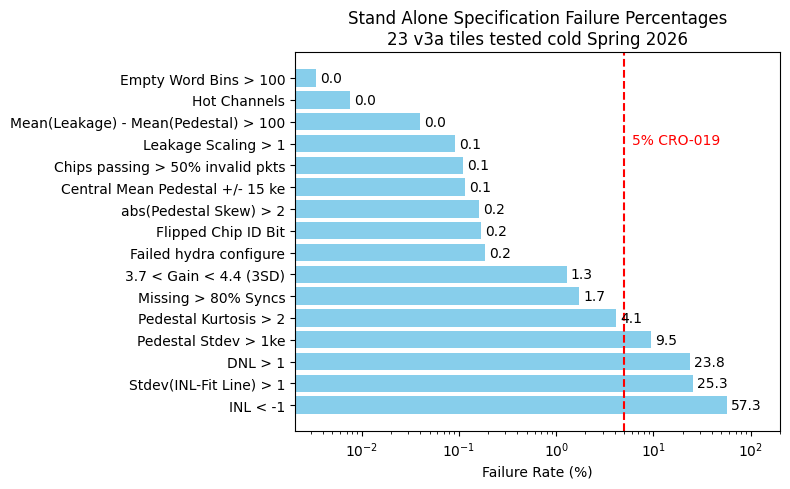

	11.4% of channels had stdev > 1000 electrons
	5.9% of channels had stdev > 1200 electrons
	3.8% of channels had stdev > 1400 electrons
	2.6% of channels had stdev > 1600 electrons
	1.8% of channels had stdev > 1800 electrons
	1.3% of channels had stdev > 2000 electrons

Maximum missing words = 439.0

Cumulative Failure Counts:
	434 channels	 Failed hydra configure
	18 channels	 Hot Channels
	248 channels	 Chips passing > 50% invalid pkts
	382 channels	 Flipped Chip ID Bit
	130824 channels	 INL < -1
	11523 channels	 Stdev(INL-Fit Line) > 1
	27991 channels	 DNL > 1
	17220 channels	 Pedestal Stdev > 1ke
	5121 channels	 Pedestal Kurtosis > 2
	70 channels	 Leakage Scaling > 1
	2823 channels	 Missing > 80% Syncs
	160 channels	 Central Mean Pedestal +/- 15 ke
	1360 channels	 3.7 < Gain < 4.4 (3SD)
	0 channels	 abs(Pedestal Skew) > 2
	23 channels	 Mean(Leakage) - Mean(Pedestal) > 100
	0 channels	 Empty Word Bins > 100
	7360 Channels	 Near analogue monitor pin


Stand Alone Failures	Cumulative

/tmp/ipykernel_145512/2003848129.py:555: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0,200)


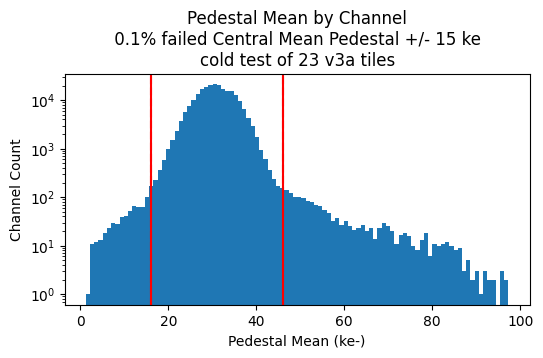

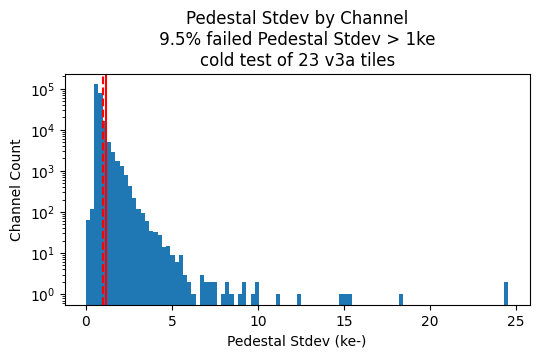

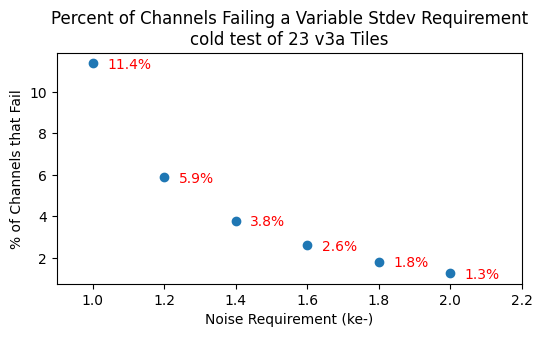

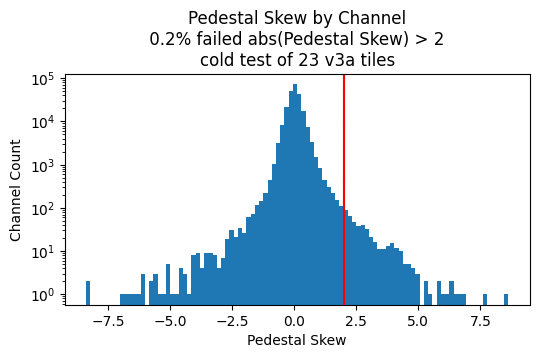

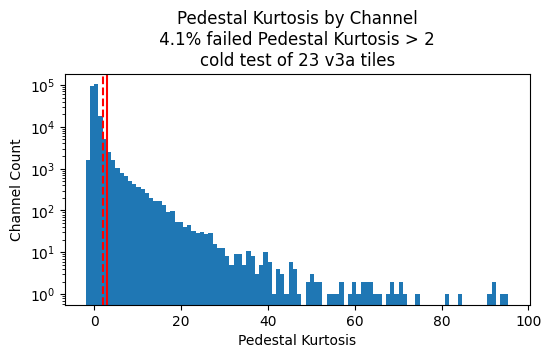

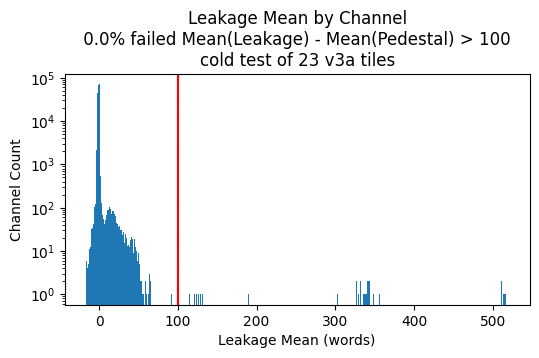

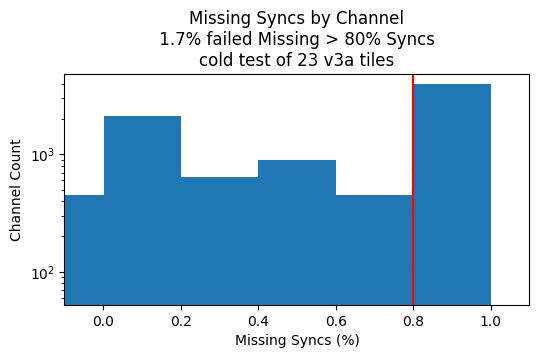

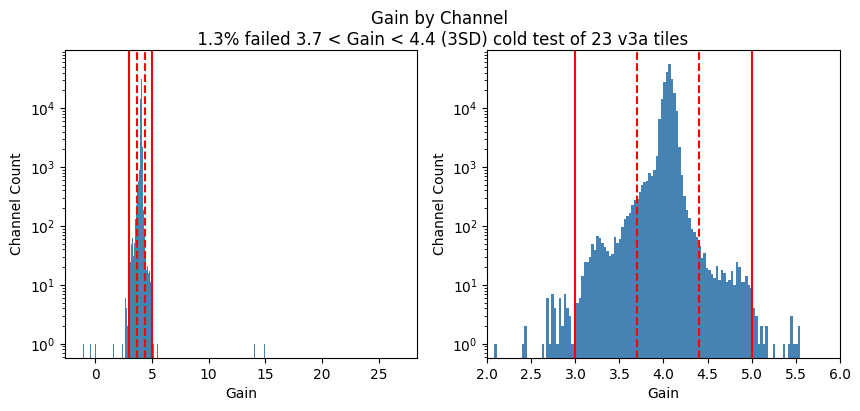

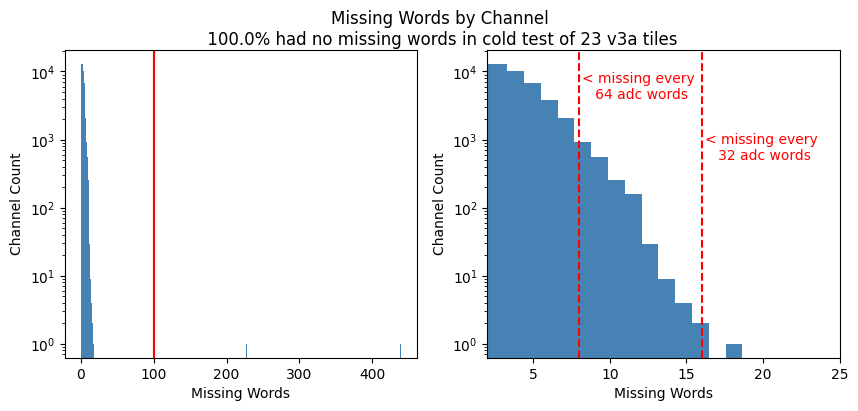

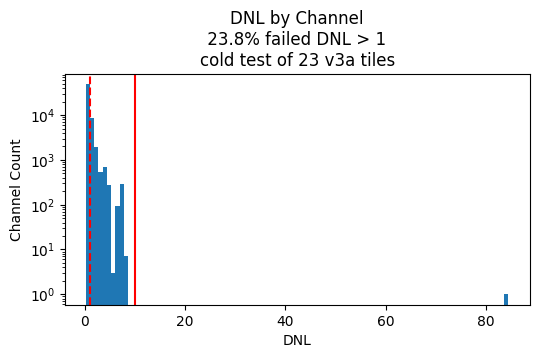

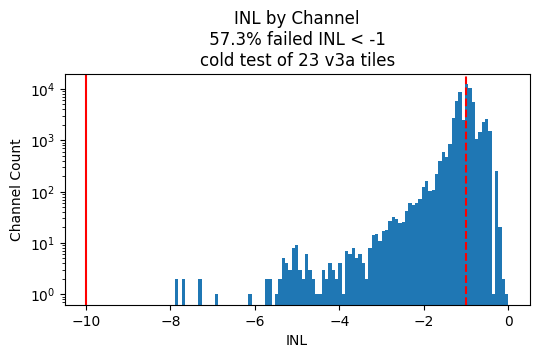

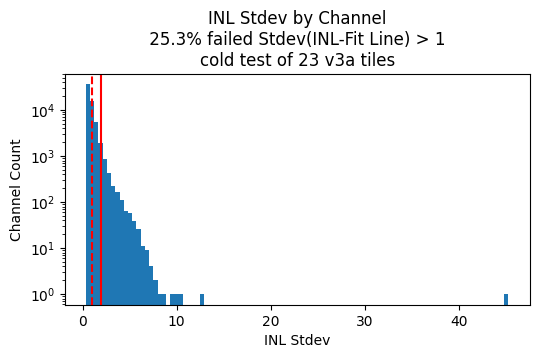

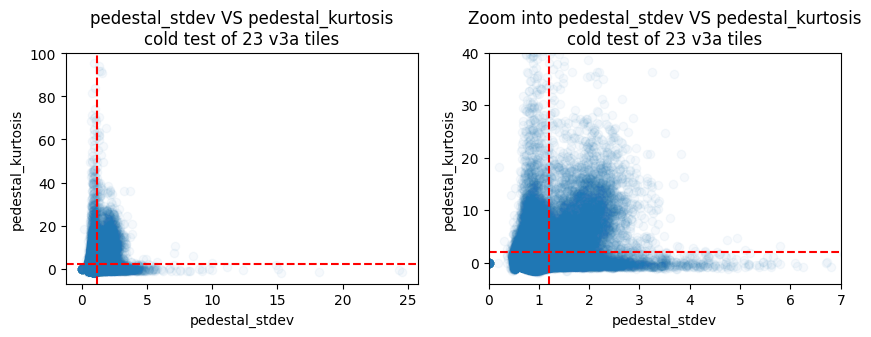

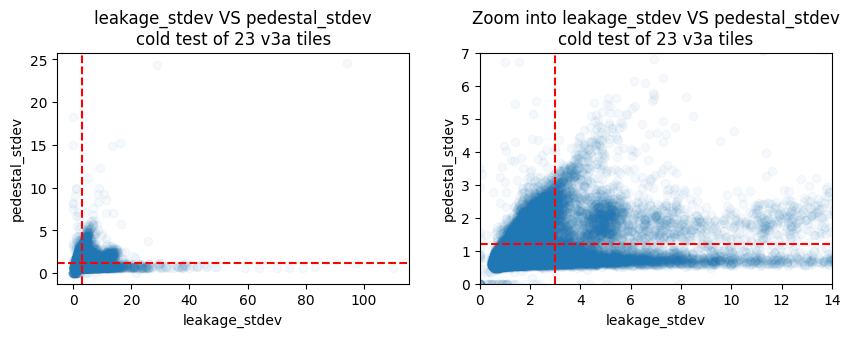

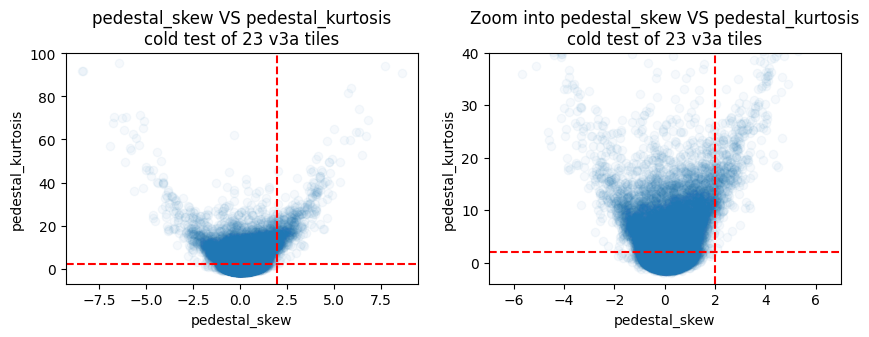

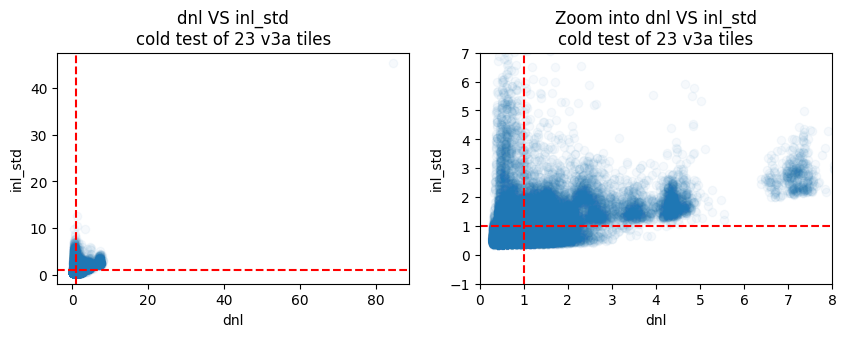

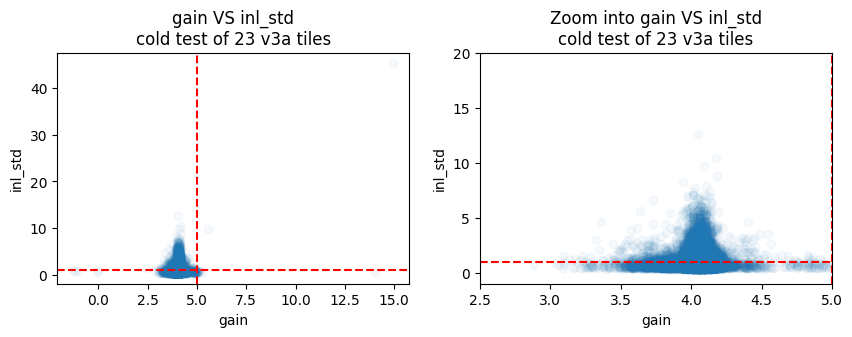

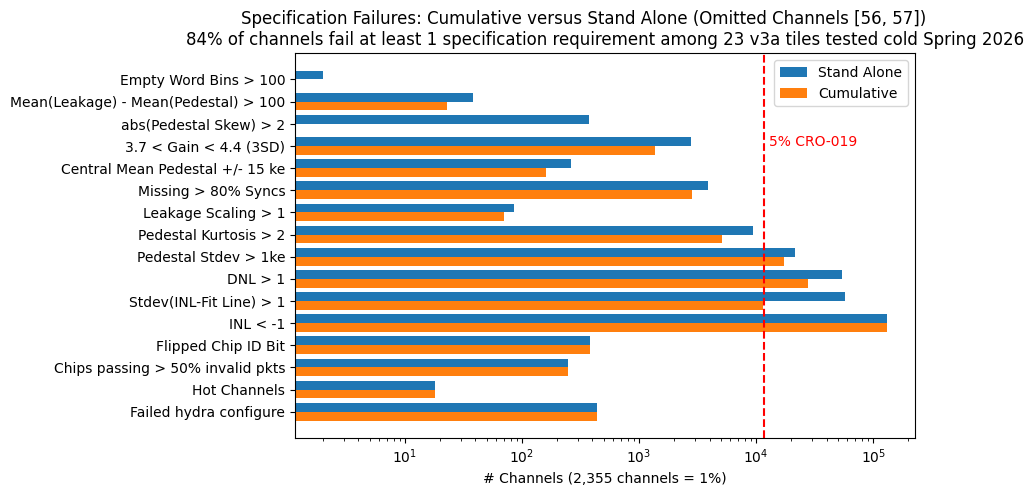

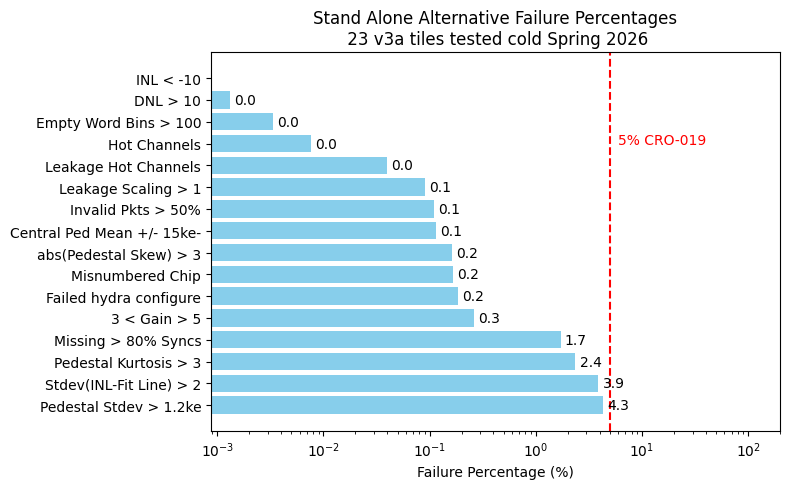


Cumulative Failure Counts:
	434 channels	 Failed hydra configure
	18 channels	 Hot Channels
	248 channels	 Invalid Pkts > 50%
	382 channels	 Misnumbered Chip
	8855 channels	 Stdev(INL-Fit Line) > 2
	9773 channels	 Pedestal Stdev > 1.2ke
	4278 channels	 Pedestal Kurtosis > 3
	81 channels	 Leakage Scaling > 1
	3508 channels	 Missing > 80% Syncs
	209 channels	 Central Ped Mean +/- 15ke-
	102 channels	 3 < Gain > 5
	0 channels	 abs(Pedestal Skew) > 3
	26 channels	 Leakage Hot Channels
	0 channels	 Empty Word Bins > 100
	7360 Channels	 Near analogue monitor pin


Stand Alone Failures	Cumulative Failures
434 	434 	 Failed hydra configure
18 	18 	 Hot Channels
248 	248 	 Invalid Pkts > 50%
382 	382 	 Misnumbered Chip
8862 	8855 	 INL < -10
9894 	9773 	 Stdev(INL-Fit Line) > 2
5390 	4278 	 DNL > 10
86 	81 	 Pedestal Stdev > 1.2ke
3906 	3508 	 Pedestal Kurtosis > 3
260 	209 	 Leakage Scaling > 1
566 	102 	 Missing > 80% Syncs
370 	0 	 Central Ped Mean +/- 15ke-
38 	26 	 3 < Gain > 5
2 	0 	 abs

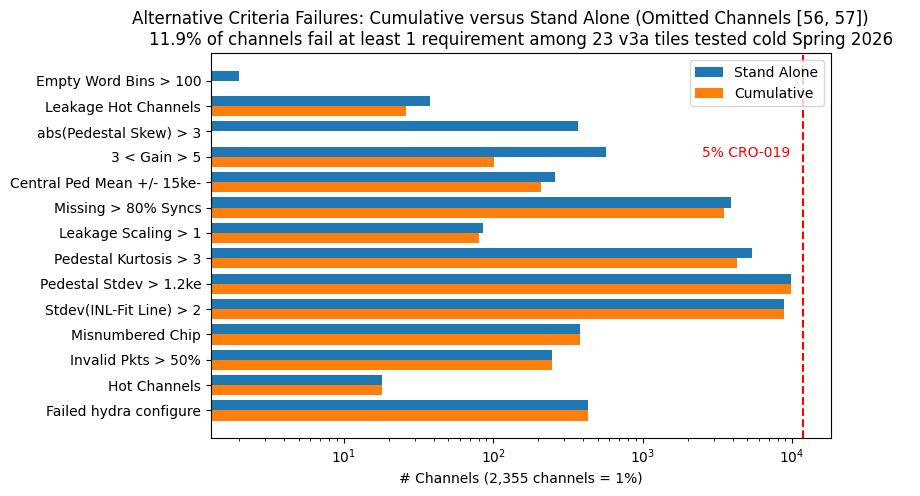

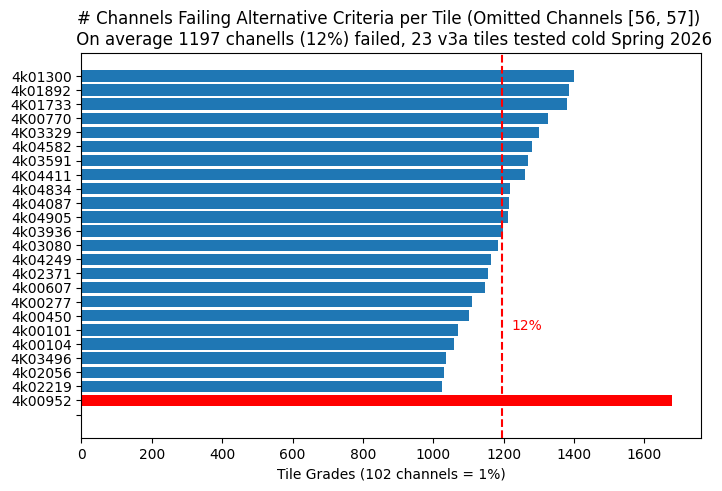

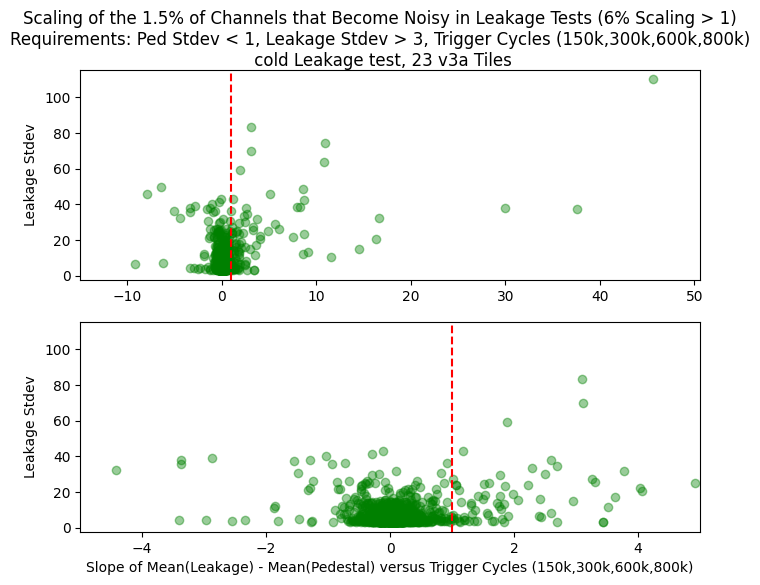

In [11]:
''' main '''

import_results_dictionary()

fix_hot_channels(results)

count_failures(results)

graph_failures()

graph_noisy_leakage(results)

store_results()
